# **Batch Normalization**

Batch Normalization is one of the most powerful breakthroughs in deep learning (introduced by Sergey Ioffe and Christian Szegedy in 2015). It is a technique used to make convolutional and dense neural networks **faster, more stable, and easier to train.**


## 1. The Core Analogy: The Moving Stage

Imagine a group of dancers performing in a line. The dancer in the back (Layer 3) has to coordinate their moves based on the position of the dancer in front of them (Layer 2), who coordinates based on the dancer in front of them (Layer 1).

* **The Problem:** As the dancers learn (weights update), the front dancers start drifting all over the stage. The dancer in the back is trying to learn their routine, but the "starting position" of the person in front of them keeps wildly shifting! This is called **Internal Covariate Shift**. It makes learning incredibly slow and chaotic.
* **The BatchNorm Solution:** BatchNorm is like drawing a chalk circle in the exact center of the stage for every dancer. No matter how much they drift, at the start of every beat, we gently pull them back to the center of their circle (Mean = 0, Variance = 1). 
* **The Result:** The dancers in the back now have a perfectly stable starting point. They can learn their routines instantly without constantly guessing where the front dancers will end up.


## 2. The Mathematical Steps (Inside a Batch)

BatchNorm normalizes the activations of a layer across a single mini-batch. Here is the exact mathematical process for a batch $B$ containing $m$ samples:

### Step 1: Calculate the Batch Mean ($\mu_B$)
Find the average activation value across the batch:

$$\mu_B = \frac{1}{m} \sum_{i=1}^{m} x_i$$

### Step 2: Calculate the Batch Variance ($\sigma_B^2$)
Find how spread out the activations are in the batch:

$$\sigma_B^2 = \frac{1}{m} \sum_{i=1}^{m} (x_i - \mu_B)^2$$

### Step 3: Normalize ($\hat{x}_i$)
Subtract the mean and divide by the standard deviation. We add a tiny number $\epsilon$ (epsilon, usually `1e-5`) to prevent division by zero:

$$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$

*Now, the activations have a **mean of 0** and a **variance of 1**.*

### Step 4: Scale and Shift ($y_i$)
If we *only* normalized, we might restrict the representation power of the network. For example, forcing a Sigmoid activation to always have a mean of 0 and variance of 1 locks it into the flat, linear region of the curve, disabling its non-linearity!

To fix this, BatchNorm introduces two **learnable parameters** that the network trains using gradient descent:
* **$\gamma$ (Gamma):** A scale factor.
* **$\beta$ (Beta):** A shift factor.

$$y_i = \gamma \hat{x}_i + \beta$$

> [!NOTE]
> The network can use $\gamma$ and $\beta$ to completely "undo" the normalization if it decides that is what's best for minimizing the loss!


## 3. Pros and Cons of Batch Normalization

### **Pros**
* **Accelerates Training:** You can use much higher learning rates ($\eta$) because the stable distributions prevent gradients from exploding or vanishing.
* **Reduces Initialization Sensitivity:** Because layers are continually normalized, your choice of weight initialization (Xavier vs. He) becomes slightly less critical.
* **Mild Regularization:** Because the mean and variance are calculated over random mini-batches, it introduces a small amount of noise. This noise acts as a regularizer, often reducing (or completely eliminating) the need for Dropout!

### **Cons**
* **Slows Down Inference (Testing):** During testing, you don't process data in batches; you might process one sample at a time. The network has to keep track of a "Running Mean" and "Running Variance" calculated during training, which adds extra book-keeping.
* **Fails with Tiny Batch Sizes:** If your batch size is extremely small (e.g., $1$ or $2$), the calculated batch mean and variance will be highly inaccurate and unstable, which ruins training. (This is why **Layer Normalization** was invented).


## 4. Where is it used in Keras Code?

BatchNorm is typically inserted **after a Dense or Convolutional layer, but before the activation function** (though sometimes it is placed after the activation function—both ways work, but placing it *before* the activation is the original paper's design).

```python
from tensorflow.keras import layers, models

model = models.Sequential([
    # 1. Linear Dense layer (no activation here!)
    layers.Dense(64, use_bias=False), 
    
    # 2. Batch Normalization (Normalizes the output of the Dense layer)
    # Note: We set use_bias=False above because Beta (β) acts as the bias!
    # if you choose use_bias=True it doesnt matter but bcoz in the formula of Batch Normalization, the bias is automatically removed, it is not needed to add bias, while doing "z = mx + b", we can just do "z = mx" 
    layers.BatchNormalization(), 
    
    # 3. Activation function is applied AFTER normalization
    layers.Activation('relu'),
    
    layers.Dense(1)
])
```

---

# **Workiing of Batch Normalization Processes (for a Single Neuron's Output)**

**IMP**<br>
- **After getting the value from $wx$ (bias is not added), it is standardized and after standardization the bias ($b$) is added and then the number it is sent to the activation function (sigmoid or TaNH), and then the final vlaue is sent to the next neuron.**
- **HOW IT WORKS : suppose there are 100 samples in a dataset, and single neuron named 'A'. The neuron A will produce different z output with respect to 100 samples and send those to the neuron in next layer. But before sending what it does is, it just takes all those 100 values of z of 100 samples, and normalizes them and then sends them to the next neuron. The same happens for all the neurons at every layer.**
- REMEMBER BATCH NORMALIZATION IS USUALLY USED IN BATCHES.




Batch Normalization (BN) stabilizes a neural network by normalizing activation values across a mini-batch of data samples. It operates on the output of a single neuron before that output splits (fans out) to connect to multiple neurons in the subsequent layer.



## 1. The Core Mechanical Pipeline

When a single neuron is connected to 20 downstream neurons in the next layer, the computational pipeline for a single forward pass executes in four distinct phases:

- [ Step 1: Compute Raw Output ]
- [ Step 2: Accumulate Mini-Batch ] ───► Calculates Batch Mean (μ) and Variance (σ²)
- [ Step 3: Transform via BN ]     ───► Applies Normalization, Scaling (γ), and Shifting (β)
- [ Step 4: Fan-Out to Next Layer ] ───► Multiplies clean scalar by 20 unique weights



## 2. Step-by-Step Execution Mechanics

### **Step 1: Raw Output Generation**
For a single input sample $k$, the neuron processes its incoming signals to generate a single, unstandardized scalar value ($z^{(k)}$):

$$z^{(k)} = \sum_{j} (x_{j}^{(k)} \cdot w_{j}) + b$$

At this point, the neuron has **not** sent anything to the next layer. The value is intercepted by the Batch Normalization step.

### **Step 2: Collecting the Mini-Batch History**
Batch Normalization cannot operate on a single isolated number. It requires a history of outputs. If your model processes a mini-batch of size $m$ (e.g., $m = 32$), this single neuron runs 32 times, creating an activation vector $\mathbf{z}$:

$$\mathbf{z} = [z^{(1)}, z^{(2)}, z^{(3)}, \dots, z^{(m)}]$$

The BN layer calculates the statistical properties of this vector across the batch dimension:

$$\mu_B = \frac{1}{m} \sum_{k=1}^{m} z^{(k)}$$

$$\sigma_B^2 = \frac{1}{m} \sum_{k=1}^{m} (z^{(k)} - \mu_B)^2$$

### **Step 3: Executing the Normalization Transform**
Using the calculated batch mean and variance, the BN layer scales every individual raw value inside that batch vector to enforce a stable distribution:

$$\hat{z}^{(k)} = \frac{z^{(k)} - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$

$$y^{(k)} = \gamma \hat{z}^{(k)} + \beta$$

Where:
* $\epsilon$ is a tiny constant preventing division by zero.
* $\gamma$ and $\beta$ are learnable parameters that allow the network to adjust the optimal scale and shift if a pure normal distribution hurts performance.

The output of this step is a single, clean, normalized scalar value $y^{(k)}$ for the current sample.

### **Step 4: The Fan-Out Step (Distribution to Next Layer)**
Now that the single value $y^{(k)}$ has been completely normalized, it is ready to leave the neuron's computational block. 

To travel to the 20 downstream neurons, this **same single normalized value** is duplicated and sent down 20 different channels. Each destination neuron $j$ applies its own unique weight ($w_{n, j}$) to that value:

$$\text{Input to Downstream Neuron}_1 = y^{(k)} \cdot w_{n,1}$$
$$\text{Input to Downstream Neuron}_2 = y^{(k)} \cdot w_{n,2}$$
$$\dots$$
$$\text{Input to Downstream Neuron}_{20} = y^{(k)} \cdot w_{n,20}$$


## 3. Structural Summary

* **Direction of Normalization:** Normalization happens **vertically** across data samples (the mini-batch axis), not horizontally across network connections (the layer width axis).
* **Isolation from Network Topology:** The Batch Normalization layer is entirely blind to the number of neurons in the next layer. It scales the single channel of data produced by the current neuron first, and hands off the resulting clean scalar to the standard matrix multiplication layer that handles the fan-out routing.



---

# **Why Batch Normalization is Needed ???**

## The Core Problem: Internal Covariate Shift

When we train a deep neural network, the weights of every layer update
simultaneously during each backward pass. This creates a chain reaction problem:

> Every time the weights in **Layer 1** change, the distribution of outputs
> that **Layer 2** receives also changes. And when Layer 2 changes, Layer 3
> is disrupted. And so on...

This constant shifting of input distributions as training progresses is called
**Internal Covariate Shift**, and it is the root cause of why deep networks
are so hard to train.


## Problem 1: Vanishing and Exploding Gradients

### What Happens?

As data flows forward through many layers, the values of `z` (pre-activation
outputs) can grow very large or shrink very small. When these extreme values
are passed into activation functions like **Sigmoid** or **Tanh**, something
dangerous happens.

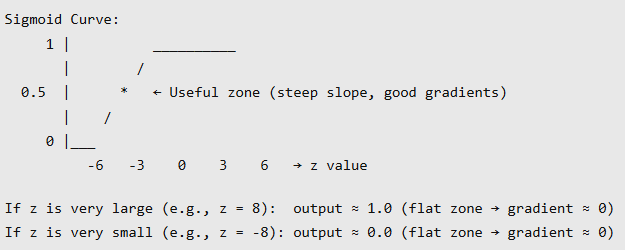

When the gradient becomes **≈ 0**, the weight update formula becomes:

$$w_{\text{new}} = w_{\text{old}} - \eta \cdot \underbrace{0}_{\text{dead gradient}}$$

The weight never updates. **The neuron is dead. Learning stops.**

### Why Does This Happen Without BatchNorm?

Without normalization, z values accumulate and shift into extreme ranges
as layers stack up:

| Layer | z value range (example) |
|:------|:------------------------|
| Layer 1 | -1 to +1 (safe zone)  |
| Layer 2 | -3 to +4 (drifting)   |
| Layer 4 | -10 to +12 (danger!)  |
| Layer 6 | -50 to +80 (dead zone)|

### How BatchNorm Fixes It

BatchNorm forces the z values back into the **safe zone** before every
activation function by normalizing them to have **Mean = 0, Variance = 1**:

$$\hat{z}_i = \frac{z_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$

No matter how deep the network goes, the input to every activation function
is always in the safe zone where gradients are healthy and non-zero.

**Technically the range is −∞ to +∞, but in practice because of standard deviation = 1, roughly 99.7% of values fall between −3 and +3 (this is the 3-sigma rule from statistics [68%, 95%, 99.7%]).**

## Problem 2: Learning Rate Sensitivity

### What Happens Without BatchNorm?

The learning rate ($\eta$) controls how big of a step we take during
gradient descent:

- If $\eta$ is **too large** → the weights overshoot, and training explodes.
- If $\eta$ is **too small** → training takes forever to converge.

Without BatchNorm, the network is so sensitive that even a slightly
wrong learning rate completely ruins training. You spend enormous time
tuning it manually.

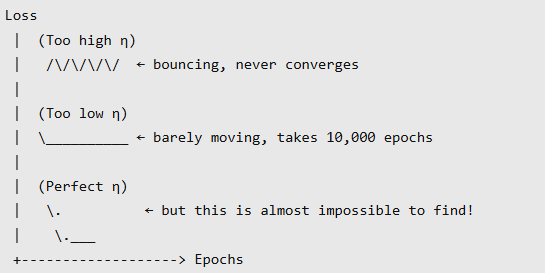

### How BatchNorm Fixes It

Because the activations are normalized at every layer, the gradients are
always in a stable, predictable range. This means:

- You can use a **much higher learning rate** without fear of explosion.
- The network converges **5x to 10x faster** in practice.
- You spend less time manually searching for the perfect $\eta$.


## Problem 3: Poor Weight Initialization

### What Happens Without BatchNorm?

Neural networks start with randomly initialized weights. If those initial
weights happen to be too large or too small, the very first forward pass
already pushes activations into dead zones. From there, the network
struggles to recover.

This is why so much research has been done on initialization strategies
like **Xavier** and **He initialization** — they exist purely to compensate
for the lack of normalization.

### How BatchNorm Fixes It

Because BatchNorm re-centers and rescales activations at every layer,
the initial weight values matter far less. Even poor initialization gets
corrected within the first few forward passes.

> **With BatchNorm:** The network is resilient to bad weight initialization.  
> **Without BatchNorm:** Bad initialization can permanently cripple training.


## Problem 4: Training is Slow and Unstable

### The Domino Effect

All three problems above combine to create a deeply unstable training process:

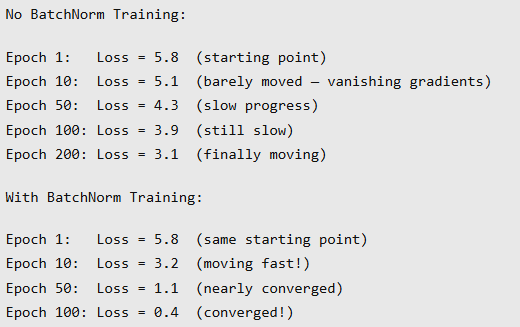

## Summary: The 4 Reasons BatchNorm is Needed

| Problem Without BatchNorm | How BatchNorm Solves It |
|:--------------------------|:------------------------|
| Vanishing / Exploding gradients | Forces z values into the safe activation zone |
| Extreme learning rate sensitivity | Stable gradients allow larger, faster learning rates |
| Poor weight initialization ruins training | Normalization corrects bad initialization at every layer |
| Slow, unstable convergence | Training is 5–10x faster and far more stable |



## The One-Line Summary

> Without Batch Normalization, deep neural networks are **fragile, slow,
> and extremely difficult to tune**. BatchNorm acts as a stabilizer that
> keeps the internal data distributions healthy, so every layer can learn
> efficiently regardless of what the layers before it are doing.

---

# **Batch Normalization During Testing / Prediction**

## The Core Problem

During **training**, BatchNorm calculates mean ($\mu$) and variance ($\sigma^2$)
from the **batch of samples**.

But during **testing/prediction**, you might only send **1 sample** to predict.
You cannot calculate a mean and variance from just 1 sample!

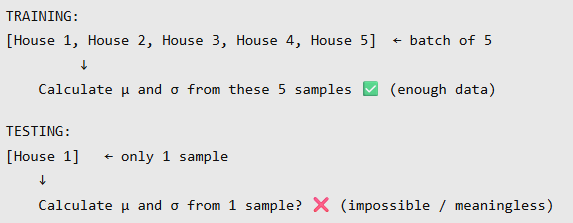

## The Solution: Running Mean and Running Variance

During **every training batch**, BatchNorm secretly keeps a **running record**
(a memory) of the mean and variance it has seen so far.

Think of it like a student taking notes during every class. When the exam
comes, they don't recalculate everything — they just **use their notes!**

### How Running Statistics are Updated (After Every Batch)

$$\mu_{\text{running}} = \underbrace{0.99 \times \mu_{\text{running (old)}}}_{\text{Keep 99\% of old memory}} + \underbrace{0.01 \times \mu_{\text{batch}}}_{\text{Add 1\% of new batch}}$$

$$\sigma^2_{\text{running}} = 0.99 \times \sigma^2_{\text{running (old)}} + 0.01 \times \sigma^2_{\text{batch}}$$

> [!NOTE]
> The value **0.99** is called **momentum**. It controls how much the model
> trusts old memory vs. the new batch. In Keras, the default momentum is 0.99.


## Step-by-Step: How Running Mean Builds Up During Training

Suppose we train for **3 batches** using our House Price dataset:

| Batch | Houses (Sq Ft) | z values | Batch Mean ($\mu$) | Running Mean (accumulated) |
|:------|:---------------|:---------|:-------------------|:---------------------------|
| 1 | 1000, 1500, 2000 | 500, 750, 1000 | 750 | $0.99(0) + 0.01(750)$ = **7.5** |
| 2 | 1200, 1800, 2200 | 600, 900, 1100 | 867 | $0.99(7.5) + 0.01(867)$ = **16.1** |
| 3 | 2500, 3000, 3200 | 1250, 1500, 1600 | 1450 | $0.99(16.1) + 0.01(1450)$ = **30.4** |

After **hundreds of batches**, the running mean and variance settle into a
**stable, representative value** of the entire dataset and stop shifting.


## During Testing: The Complete Flow

When you send **1 new house** (e.g., 2,250 sq ft) for prediction:

## Training vs Testing: Side by Side

| | Training | Testing / Prediction |
|:---|:---|:---|
| **Mean used** | $\mu_{\text{batch}}$ (from current batch) | $\mu_{\text{running}}$ (from training memory) |
| **Variance used** | $\sigma^2_{\text{batch}}$ (from current batch) | $\sigma^2_{\text{running}}$ (from training memory) |
| **γ and β** | Being learned (updating every epoch) | Fixed (already learned, frozen) |
| **Batch size needed?** | Yes (minimum 2–3 samples) | ❌ No! Works with just 1 sample |

<br><br>
> Keras automatically switches BatchNorm between training mode and inference mode depending on whether you call model.fit() or model.predict(). You never have to manage this manually.

> During testing, BatchNorm does not calculate anything new. It simply uses the running mean and variance collected during training as a frozen memory, and normalizes using those fixed values. This is why it works perfectly even with just 1 sample at prediction time.
<br><br>

## In Code: This Happens Automatically

```python
# TRAINING MODE
# BatchNorm uses batch mean/variance AND updates running statistics
model.fit(X_train, y_train, epochs=100)

# TESTING MODE
# BatchNorm automatically switches to running mean/variance
# No extra code needed — Keras handles this internally!
predictions = model.predict(X_test)

# You can inspect the stored running statistics like this:
bn_layer = model.layers[1]

print("Running Mean    :", bn_layer.moving_mean.numpy())
print("Running Variance:", bn_layer.moving_variance.numpy())
print("Learned Gamma   :", bn_layer.gamma.numpy())
print("Learned Beta    :", bn_layer.beta.numpy())
```